# Introduction to Deep Learning Final Project

Üç farklı derin öğrenme modeli bulunyor.

Kullanılan modeller:

1. **CNN** ile doğal sahne görüntülerini sınıflandırma  
2. **RNN tabanlı LSTM** ile Türkçe film yorumlarından duygu analizi  
3. **Autoencoder** ile doğal sahne görüntülerini yeniden oluşturma


Veri setleri:
- Intel Image Classification: `puneet6060/intel-image-classification`
- Turkish Movie Sentiment Analysis Dataset: `mustfkeskin/turkish-movie-sentiment-analysis-dataset`

## 1. Kütüphaneler

Bu hücrede projede kullanacağımız temel kütüphaneleri çağırıyorum. TensorFlow/Keras model kurmak için, pandas veri okumak için, matplotlib grafik çizmek için, scikit-learn ise train/test ayrımı ve metrikler için kullanılıyoruz

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-05-19 14:48:55.576052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779202135.792091      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779202135.852788      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779202136.329455      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779202136.329495      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779202136.329498      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Dataset path 
Pathi doğru yazmak çok önemli boşuna çok zaman kaybettim.



In [2]:
IMAGE_BASE_DIR = "/kaggle/input/datasets/puneet6060/intel-image-classification"
TRAIN_DIR = IMAGE_BASE_DIR + "/seg_train/seg_train"
TEST_DIR = IMAGE_BASE_DIR + "/seg_test/seg_test"

TEXT_CSV_PATH = "/kaggle/input/datasets/mustfkeskin/turkish-movie-sentiment-analysis-dataset/turkish_movie_sentiment_dataset.csv"

# Bölüm 1: CNN ile Image Classification

Bu bölümde **Intel Image Classification** veri setindeki doğal sahne görüntülerini sınıflandırıyorum. Bu veri seti Kaggle'da hazır olarak 6 sınıf/klasör halinde geliyor: **buildings, forest, glacier, mountain, sea ve street**.

Burada sınıfları ben kendim oluşturmadım. TensorFlow, klasör isimlerini otomatik olarak sınıf etiketi olarak okuyor. CNN modelinin amacı, verilen bir görüntünün bu hazır 6 sınıftan hangisine ait olduğunu tahmin etmektir.

## 3. CNN için görüntü verisini hazırlama

Görüntüleri 128x128 boyutuna getiriyorum. Bu boyut çok küçük olmadığı için görüntü bilgisini tamamen kaybetmiyor, ama eğitim süresini de aşırı uzatmıyor. Batch size değerini 32 seçtim çünkü görüntü modellerinde sık kullanılan, GPU belleğini çok zorlamayan dengeli bir değer.

Train klasöründen %20 validation ayırıyorum. Test klasörü zaten ayrı geldiği için onu eğitimde kullanmıyorum.

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE_IMG = 32

cnn_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE_IMG
)

cnn_val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE_IMG
)

cnn_test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE_IMG,
    shuffle=False
)

class_names = cnn_train_ds.class_names
num_classes = len(class_names)

print("Sınıf isimleri:", class_names)
print("Sınıf sayısı:", num_classes)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1779202173.844673      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779202173.850677      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Sınıf isimleri: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Sınıf sayısı: 6


## 4. CNN için normalizasyon

Görüntüler ilk yüklendiğinde piksel değerleri 0-255 aralığında geliyor. Modelin daha rahat öğrenmesi için bunları 0-1 aralığına indiriyorum. Bu işlem eğitim sürecini daha stabil hale getirir.

In [4]:
normalization_layer = layers.Rescaling(1./255)

cnn_train_ds = cnn_train_ds.map(lambda images, labels: (normalization_layer(images), labels))
cnn_val_ds = cnn_val_ds.map(lambda images, labels: (normalization_layer(images), labels))
cnn_test_ds = cnn_test_ds.map(lambda images, labels: (normalization_layer(images), labels))

AUTOTUNE = tf.data.AUTOTUNE
cnn_train_ds = cnn_train_ds.prefetch(AUTOTUNE)
cnn_val_ds = cnn_val_ds.prefetch(AUTOTUNE)
cnn_test_ds = cnn_test_ds.prefetch(AUTOTUNE)

## 5. CNN model mimarisi

Modelde üç tane convolution bloğu kullandım. Her blokta önce görüntüden özellik çıkarılıyor, sonra MaxPooling ile boyut küçültülüyor. En sonda Flatten ile görüntü özellikleri tek boyutlu hale getiriliyor ve Dense katmanları ile sınıflandırma yapılıyor.

Son katmanda 6 sınıf olduğu için `softmax` kullandım. Etiketler integer olarak geldiği için loss function olarak `sparse_categorical_crossentropy` seçtim. Optimizer olarak Adam kullandım çünkü başlangıç için genelde iyi ve stabil çalışan bir optimizer.

In [5]:
cnn_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. CNN modelini eğitme

CNN için epoch sayısını 15 seçtim. Çok az epoch modelin yeterince öğrenmemesine sebep olabilir. Çok fazla epoch ise bu veri setinde overfitting riskini artırabilir. Bu yüzden 15 epoch bu proje için makul bir başlangıç değeridir.

In [6]:
CNN_EPOCHS = 15

history_cnn = cnn_model.fit(
    cnn_train_ds,
    validation_data=cnn_val_ds,
    epochs=CNN_EPOCHS
)

Epoch 1/15


I0000 00:00:1779202184.180555     134 service.cc:152] XLA service 0x7cc9d0008020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779202184.180601     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779202184.180606     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779202184.666830     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-19 14:49:46.453892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:49:46.602279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 10/351 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1924 - loss: 1.7583

I0000 00:00:1779202188.681868     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5248 - loss: 1.1782

2026-05-19 14:50:05.246449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:50:05.394099: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.5252 - loss: 1.1773 - val_accuracy: 0.6768 - val_loss: 0.8216
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7207 - loss: 0.7519 - val_accuracy: 0.7227 - val_loss: 0.6953
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7749 - loss: 0.6179 - val_accuracy: 0.8065 - val_loss: 0.5450
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8292 - loss: 0.4833 - val_accuracy: 0.8047 - val_loss: 0.5702
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8578 - loss: 0.3970 - val_accuracy: 0.7997 - val_loss: 0.6157
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8926 - loss: 0.3026 - val_accuracy: 0.8136 - val_loss: 0.6733
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9059 - loss: 0.2569 - val_accuracy: 0.8193 - val_loss: 0.6723
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9272 - loss: 0.1978 - val_accuracy: 0.81

## 7. CNN loss ve accuracy grafikleri

Bu grafiklerde train ve validation değerlerini birlikte gösteriyorum. Eğer train accuracy artarken validation accuracy çok geride kalırsa overfitting olabilir. Eğer ikisi de düşük kalırsa modelin yetersiz öğrenmesi yani underfitting olabilir.

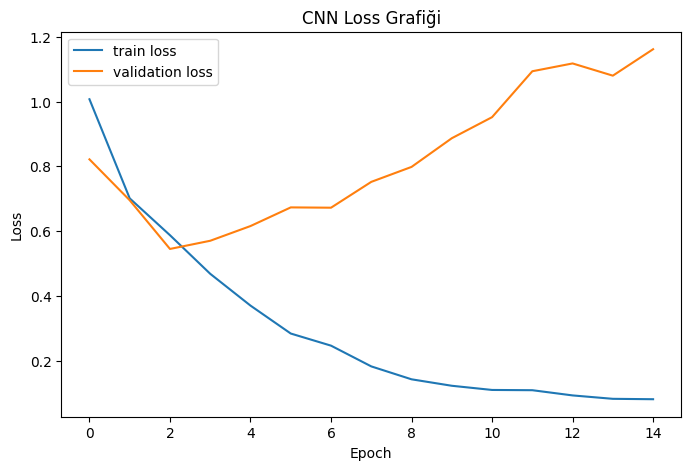

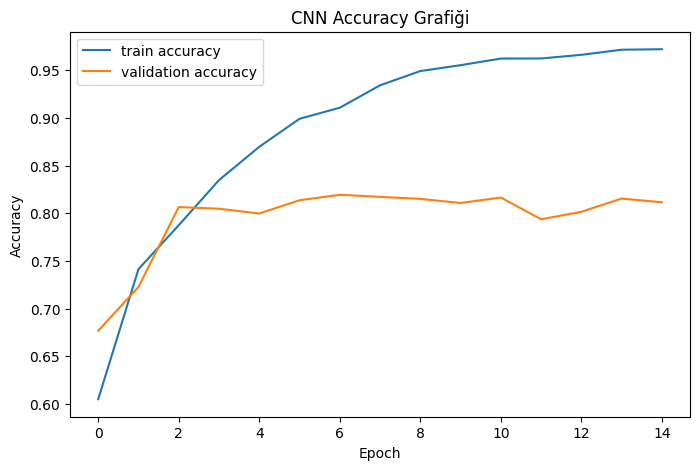

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["loss"], label="train loss")
plt.plot(history_cnn.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Grafiği")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], label="train accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Grafiği")
plt.legend()
plt.show()

## 8. CNN test performansı

Bu bölümde modeli test seti üzerinde değerlendiriyorum. Test seti eğitim sırasında kullanılmadığı için modelin daha önce görmediği görüntülerdeki başarısını gösterir.

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(cnn_test_ds)
print("CNN test loss:", cnn_test_loss)
print("CNN test accuracy:", cnn_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.8232 - loss: 1.0170
CNN test loss: 1.0416111946105957
CNN test accuracy: 0.8066666722297668


## 9. CNN confusion matrix ve classification report

Confusion matrix hangi sınıfların birbirine karıştırıldığını gösterir. Classification report ise precision, recall ve F1-score değerlerini verir. Bu değerler sadece genel accuracy'ye bakmaktan daha ayrıntılı yorum yapmamı sağlar.

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
              precision    recall  f1-score   support

   buildings       0.74      0.80      0.77       437
      forest       0.94      0.96      0.95       474
     glacier       0.75      0.78      0.77       553
    mountain       0.77      0.75      0.76       525
         sea       0.83      0.76      0.79       510
      street       0.82      0.80      0.81       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



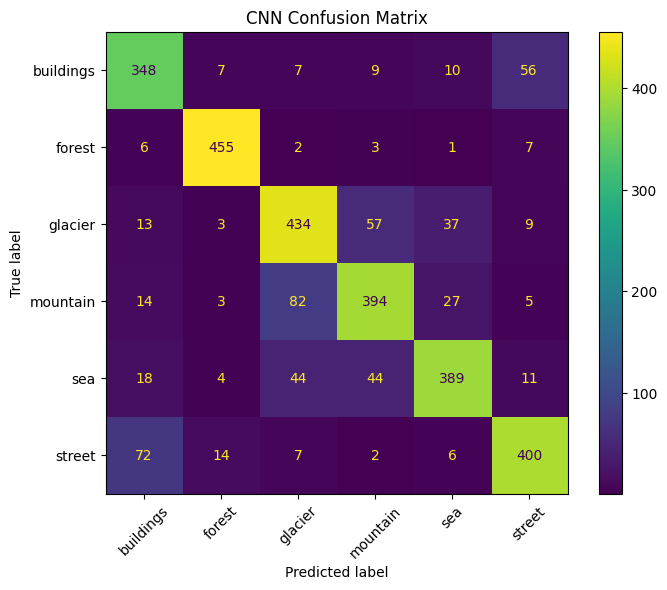

In [9]:
y_true_cnn = np.concatenate([labels.numpy() for images, labels in cnn_test_ds])
y_prob_cnn = cnn_model.predict(cnn_test_ds)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp_cnn.plot(ax=ax, xticks_rotation=45)
plt.title("CNN Confusion Matrix")
plt.show()

## 10. CNN örnek tahminler

Burada test setinden birkaç görüntü alıp modelin tahminini gösteriyorum. Bu kısım sunumda faydalı olur çünkü modelin çıktısını görsel olarak anlatmak kolaylaşır.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step


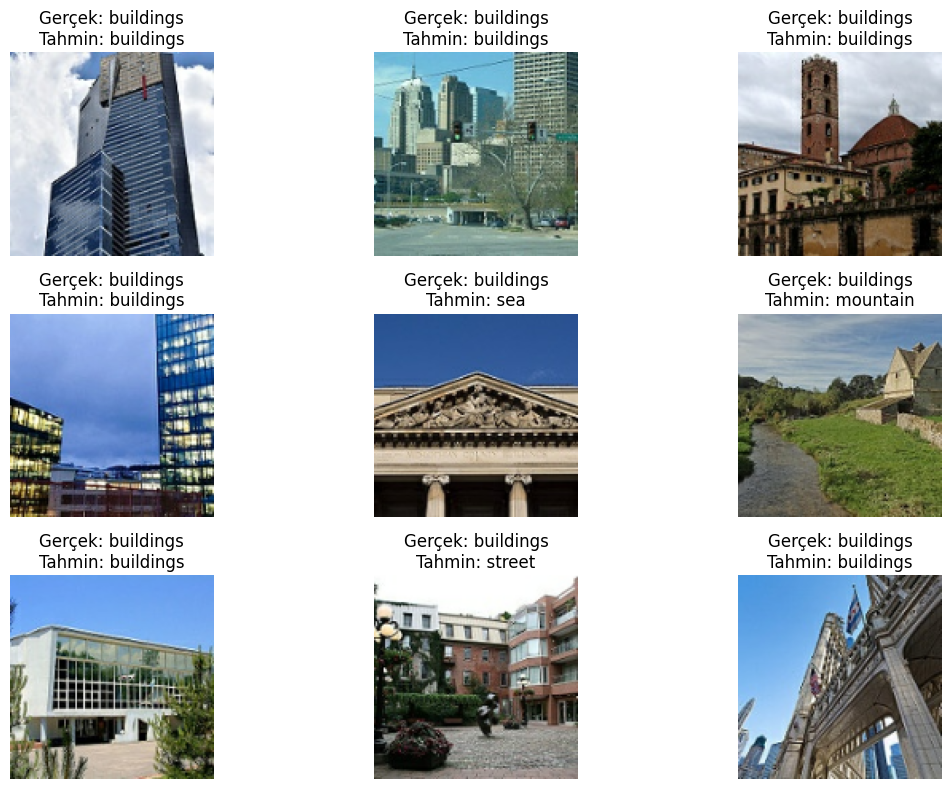

In [10]:
for images, labels in cnn_test_ds.take(1):
    probs = cnn_model.predict(images)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_names[int(labels[i])]
        pred_label = class_names[int(preds[i])]
        plt.title("Gerçek: " + true_label + "\nTahmin: " + pred_label)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Bölüm 2: LSTM ile Türkçe Duygu Analizi

Bu bölümde Türkçe film yorumlarını kullanarak yorumun duygu sınıfını tahmin etmeye çalışıyorum. Orijinal veri setinde yorumlar ve 0-5 arası puanlar var. Bu puanları üç sınıfa çevirdim:

- 0: negatif
- 1: nötr
- 2: pozitif

Text data sıralı bir veri olduğu için LSTM seçtim. LSTM, kelime sırasını dikkate alabildiği için klasik dense modele göre metinlerde daha uygun bir seçimdir.

## 11. Text veri setini okuma

Bu hücrede CSV dosyasını pandas ile okuyorum. Sadece yorum ve puan kolonlarını kullanıyorum. Puan değerlerinden sınıf etiketi üreteceğim.

In [11]:
df_text = pd.read_csv(TEXT_CSV_PATH)

# Kolon isimlerini küçük harfe çeviriyorum. Böylece Comment/comment farkı sorun olmaz.
df_text.columns = [col.strip().lower() for col in df_text.columns]

print(df_text.head())
print(df_text.columns)
print("Satır sayısı:", len(df_text))

                                             comment      film_name point
0  \n                      Jean Reno denince zate...  Sevginin Gücü   5,0
1  \n                      Ekşın falan izlemek is...  Sevginin Gücü   5,0
2  \n                      Bu yapım hakkında öyle...  Sevginin Gücü   5,0
3  \n                      finali yeter... (sting...  Sevginin Gücü   5,0
4  \n                      Jean Reno..\r\nbu adam...  Sevginin Gücü   5,0
Index(['comment', 'film_name', 'point'], dtype='object')
Satır sayısı: 83227


## 12. Text verisini temizleme ve etiket oluşturma

Yorum kolonunu string formata çeviriyorum. Puan kolonunu da sayısal formata çeviriyorum. Daha sonra puana göre negatif, nötr ve pozitif etiketleri oluşturuyorum.

Etiketleme mantığım:

- `point < 2` ise negatif
- `2 <= point < 4` ise nötr
- `point >= 4` ise pozitif

Bu sınıflandırma tamamen veri setindeki puan bilgisinden üretildiği için sunumda açıklaması kolaydır.

In [12]:
df_text = df_text[["comment", "point"]].dropna()

df_text["comment"] = df_text["comment"].astype(str)
df_text["comment"] = df_text["comment"].str.lower()

# point sütununu güvenli şekilde sayıya çeviriyorum
# Bazı değerler 4,5 gibi virgüllü gelebileceği için önce virgülü noktaya çeviriyorum
df_text["point"] = df_text["point"].astype(str)
df_text["point"] = df_text["point"].str.replace(",", ".", regex=False)
df_text["point"] = pd.to_numeric(df_text["point"], errors="coerce")

# Sayıya çevrilemeyen puanları siliyorum
df_text = df_text.dropna(subset=["point"])

def point_to_label(point):
    if point < 2:
        return 0
    elif point < 4:
        return 1
    else:
        return 2

df_text["label"] = df_text["point"].apply(point_to_label).astype("int32")

label_names_text = ["negatif", "notr", "pozitif"]

print(df_text[["comment", "point", "label"]].head())
print("Label dağılımı:")
print(df_text["label"].value_counts().sort_index())
print("Satır sayısı:", len(df_text))

                                             comment  point  label
0  \n                      jean reno denince zate...    5.0      2
1  \n                      ekşın falan izlemek is...    5.0      2
2  \n                      bu yapım hakkında öyle...    5.0      2
3  \n                      finali yeter... (sting...    5.0      2
4  \n                      jean reno..\r\nbu adam...    5.0      2
Label dağılımı:
label
0    11531
1    28360
2    43336
Name: count, dtype: int64
Satır sayısı: 83227


## 13. Dengeli örneklem alma

Veri setindeki sınıflar eşit olmayabilir. Çok dengesiz bir veriyle eğitim yaparsam model çoğunluk sınıfına kayabilir. Bu yüzden her sınıftan mümkün olduğunca eşit sayıda örnek alıyorum.

Burada her sınıftan en fazla 15000 yorum aldım. Bu sayı Kaggle GPU için çok ağır değildir ama LSTM'in öğrenmesi için de yeterli büyüklüktedir.

In [13]:
SAMPLE_PER_CLASS = 15000
sampled_parts = []

for label_id in sorted(df_text["label"].unique()):
    class_part = df_text[df_text["label"] == label_id]
    sample_size = min(SAMPLE_PER_CLASS, len(class_part))
    
    if sample_size > 0:
        sampled_parts.append(class_part.sample(n=sample_size, random_state=SEED))

text_data = pd.concat(sampled_parts)
text_data = text_data.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Kullanılan toplam yorum sayısı:", len(text_data))
print("Dengelenmiş label dağılımı:")
print(text_data["label"].value_counts().sort_index())

Kullanılan toplam yorum sayısı: 41531
Dengelenmiş label dağılımı:
label
0    11531
1    15000
2    15000
Name: count, dtype: int64


## 14. Train, validation ve test ayrımı

Veriyi önce train ve geçici veri olarak ayırıyorum. Sonra geçici veriyi validation ve test olarak ikiye bölüyorum. Böylece yaklaşık olarak %70 train, %15 validation ve %15 test ayrımı oluşuyor.

`stratify` kullanmamın sebebi her bölümde sınıf dağılımını benzer tutmaktır.

In [14]:
X = text_data["comment"].values.astype(str)
y = text_data["label"].values.astype("int32")

X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text,
    y_temp_text,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_text
)

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 29071
Validation: 6230
Test: 6230


## 15. Tokenization ve padding

LSTM doğrudan metin cümlesi alamaz. Bu yüzden kelimeleri sayılara çeviriyorum. `Tokenizer` en sık geçen kelimeler için bir sözlük oluşturur. Daha sonra her yorumu sayı dizisine çevirir.

Yorum uzunlukları farklı olduğu için hepsini aynı uzunluğa getiriyorum. Bunun için `pad_sequences` kullanıyorum. Maximum sequence length değerini 80 seçtim. Bu değer çok kısa yorumları boşa büyütmez, uzun yorumların da ilk kısmını alarak modeli daha hızlı eğitir.

TensorFlow dtype hatası çıkmaması için padding sonucu oluşan dizileri özellikle `int32` tipine çeviriyorum.

In [15]:
VOCAB_SIZE = 20000
MAX_LEN = 80

text_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
text_tokenizer.fit_on_texts(X_train_text)

X_train_seq = text_tokenizer.texts_to_sequences(X_train_text)
X_val_seq = text_tokenizer.texts_to_sequences(X_val_text)
X_test_seq = text_tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
).astype("int32")

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
).astype("int32")

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
).astype("int32")

y_train_text = y_train_text.astype("int32")
y_val_text = y_val_text.astype("int32")
y_test_text = y_test_text.astype("int32")

print("Train tensor shape:", X_train_pad.shape)
print("Train dtype:", X_train_pad.dtype)
print("Label dtype:", y_train_text.dtype)

Train tensor shape: (29071, 80)
Train dtype: int32
Label dtype: int32


## 16. LSTM model mimarisi

Embedding katmanı kelimeleri sayısal vektörlere dönüştürür. LSTM katmanı kelime sırasındaki bilgiyi öğrenir. Dropout katmanı overfitting riskini azaltmak için kullanılır. Son katman 3 sınıf için softmax üretir.

Loss function olarak yine `sparse_categorical_crossentropy` kullandım çünkü etiketler 0, 1 ve 2 şeklinde integer. Optimizer olarak Adam seçtim.

In [16]:
lstm_model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.LSTM(64),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,203 (5.02 MB)

 Trainable params: 1,315,203 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

## 17. LSTM modelini eğitme

LSTM için epoch sayısını 6 seçtim. Text verisi görüntüye göre daha hızlı overfit olabilir. Bu yüzden çok fazla epoch kullanmadım. Batch size değerini 128 seçtim çünkü text verisinde bu değer eğitim süresini makul tutar.

In [17]:
LSTM_EPOCHS = 6
BATCH_SIZE_TEXT = 128

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train_text,
    validation_data=(X_val_pad, y_val_text),
    epochs=LSTM_EPOCHS,
    batch_size=BATCH_SIZE_TEXT
)

Epoch 1/6
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3603 - loss: 1.0934 - val_accuracy: 0.3604 - val_loss: 1.0912
Epoch 2/6
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3706 - loss: 1.0879 - val_accuracy: 0.3613 - val_loss: 1.0893
Epoch 3/6
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3815 - loss: 1.0722 - val_accuracy: 0.3655 - val_loss: 1.0947
Epoch 4/6
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4106 - loss: 1.0317 - val_accuracy: 0.3682 - val_loss: 1.1323
Epoch 5/6
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4370 - loss: 0.9885 - val_accuracy: 0.3745 - val_loss: 1.1540
Epoch 6/6
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4253 - loss: 0.9777 - val_accuracy: 0.3753 - val_loss: 1.1863


## 18. LSTM loss ve accuracy grafikleri

Bu grafiklerde LSTM'in eğitim boyunca nasıl değiştiğini görüyorum. Validation loss artmaya başlarsa model eğitim verisini ezberlemeye başlamış olabilir.

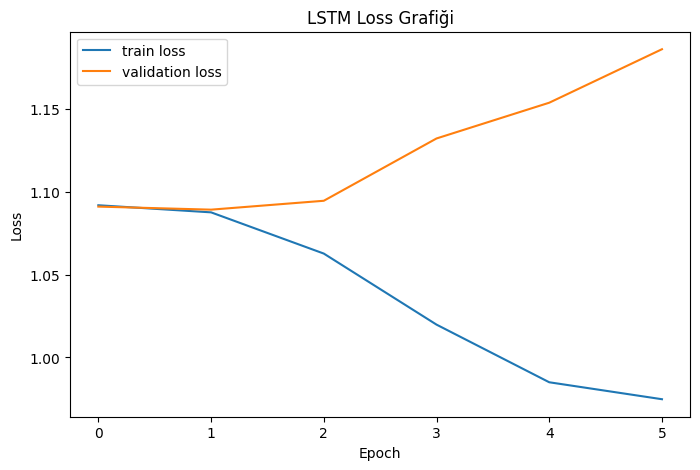

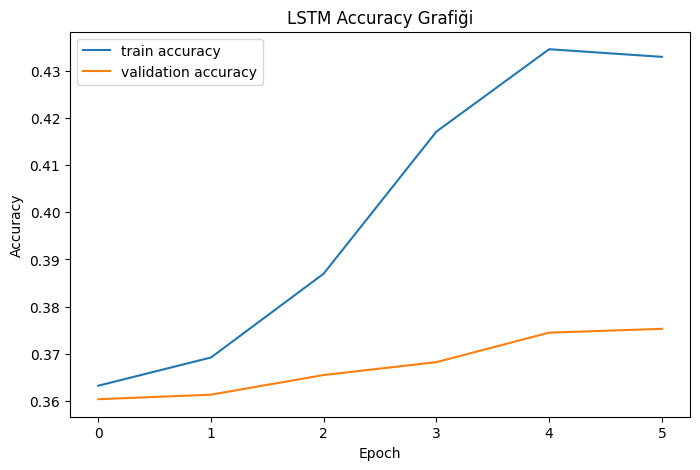

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss Grafiği")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["accuracy"], label="train accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy Grafiği")
plt.legend()
plt.show()

## 19. LSTM test performansı

Test verisi eğitim ve validation sırasında kullanılmadığı için gerçek performans yorumu için önemlidir.

In [19]:
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_pad, y_test_text)
print("LSTM test loss:", lstm_test_loss)
print("LSTM test accuracy:", lstm_test_acc)

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3723 - loss: 1.2046
LSTM test loss: 1.185829520225525
LSTM test accuracy: 0.3733547329902649


## 20. LSTM confusion matrix ve classification report

Bu bölümde hangi duygu sınıflarının birbirine karıştığını inceliyorum. Özellikle nötr sınıf, negatif ve pozitif arasında kaldığı için modelin zorlanabileceği bir sınıftır.

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

     negatif       0.46      0.04      0.08      1730
        notr       0.48      0.05      0.09      2250
     pozitif       0.37      0.95      0.53      2250

    accuracy                           0.37      6230
   macro avg       0.44      0.35      0.23      6230
weighted avg       0.43      0.37      0.25      6230



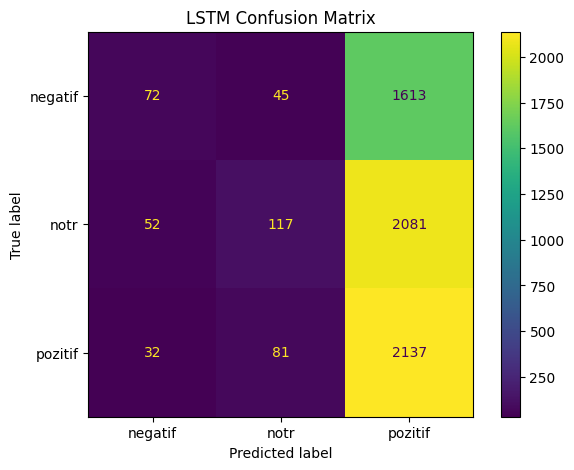

In [20]:
y_prob_lstm = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_prob_lstm, axis=1)

print(classification_report(y_test_text, y_pred_lstm, target_names=label_names_text))

cm_lstm = confusion_matrix(y_test_text, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=label_names_text)

fig, ax = plt.subplots(figsize=(7, 5))
disp_lstm.plot(ax=ax)
plt.title("LSTM Confusion Matrix")
plt.show()

## 21. LSTM örnek tahminler

Bu hücrede kendi yazdığım birkaç Türkçe yorum üzerinde modelin tahminini deniyorum. Sunumda bu kısım modeli anlatmak için kullanışlı olur.

In [21]:
example_sentences = [
    "Film çok güzeldi, oyunculukları ve hikayeyi beğendim.",
    "Çok sıkıcıydı, zaman kaybı olduğunu düşünüyorum.",
    "Ortalama bir filmdi, bazı sahneleri iyi bazı sahneleri zayıftı."
]

example_seq = text_tokenizer.texts_to_sequences(np.array(example_sentences, dtype=str))
example_pad = pad_sequences(
    example_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
).astype("int32")

example_probs = lstm_model.predict(example_pad)
example_preds = np.argmax(example_probs, axis=1)

for sentence, pred, prob in zip(example_sentences, example_preds, example_probs):
    print("Yorum:", sentence)
    print("Tahmin:", label_names_text[int(pred)])
    print("Olasılıklar:", prob)
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Yorum: Film çok güzeldi, oyunculukları ve hikayeyi beğendim.
Tahmin: pozitif
Olasılıklar: [0.2855922  0.35519844 0.35920933]
------------------------------------------------------------
Yorum: Çok sıkıcıydı, zaman kaybı olduğunu düşünüyorum.
Tahmin: pozitif
Olasılıklar: [0.28559196 0.35519856 0.35920945]
------------------------------------------------------------
Yorum: Ortalama bir filmdi, bazı sahneleri iyi bazı sahneleri zayıftı.
Tahmin: pozitif
Olasılıklar: [0.28559282 0.35519812 0.35920903]
------------------------------------------------------------


# Bölüm 3: Autoencoder ile Image Reconstruction

Bu bölümde yine Intel Image Classification görüntülerini kullanıyorum ama bu sefer sınıf etiketlerini kullanmıyorum. Modelin amacı görüntüyü sınıflandırmak değil, görüntüyü sıkıştırılmış bir temsil üzerinden yeniden oluşturmaktır.

Autoencoder iki ana kısımdan oluşur:

- **Encoder:** Görüntüyü daha küçük bir temsile sıkıştırır.
- **Decoder:** Bu sıkıştırılmış temsilden görüntüyü yeniden üretmeye çalışır.

Bu bölümde accuracy metriği kullanmıyorum çünkü problem sınıflandırma problemi değil. Bunun yerine reconstruction loss ve görsel karşılaştırma kullanıyorum.

## 22. Autoencoder için görüntü verisini hazırlama

Bu kez etiketlere ihtiyacım yok. Görüntüyü hem giriş hem de hedef olarak kullanıyorum. Yani modelin öğrenmeye çalıştığı şey şudur: input görüntüyü al ve output olarak aynı görüntüyü üret.

In [22]:
ae_train_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE_IMG,
    label_mode=None
)

ae_val_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE_IMG,
    label_mode=None
)

ae_test_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE_IMG,
    label_mode=None,
    shuffle=True,
    seed=SEED
)

# Autoencoder'da hedef görüntü giriş görüntüsünün aynısıdır.
def prepare_autoencoder_data(images):
    images = tf.cast(images, tf.float32) / 255.0
    return images, images

ae_train_ds = ae_train_raw.map(prepare_autoencoder_data).prefetch(AUTOTUNE)
ae_val_ds = ae_val_raw.map(prepare_autoencoder_data).prefetch(AUTOTUNE)
ae_test_ds = ae_test_raw.map(prepare_autoencoder_data).prefetch(AUTOTUNE)

Found 14034 files.
Using 11228 files for training.
Found 14034 files.
Using 2806 files for validation.
Found 3000 files.


## 23. Autoencoder model mimarisi

Encoder kısmında MaxPooling ile görüntü boyutu küçülüyor. Decoder kısmında UpSampling ile görüntü tekrar eski boyutuna getiriliyor. Son katmanda `sigmoid` kullandım çünkü görüntü pikselleri 0-1 aralığında.

Loss function olarak `mse` kullandım. Çünkü modelin çıktısı ile gerçek görüntü arasındaki piksel farkını azaltmasını istiyorum.

In [23]:
autoencoder = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## 24. Autoencoder modelini eğitme

Autoencoder için epoch sayısını 20 seçtim. Reconstruction problemi sınıflandırmaya göre biraz daha fazla epoch isteyebilir. Yine de proje süresini çok uzatmamak için çok yüksek bir epoch değeri seçmedim.

In [24]:
AE_EPOCHS = 20

history_ae = autoencoder.fit(
    ae_train_ds,
    validation_data=ae_val_ds,
    epochs=AE_EPOCHS
)

Epoch 1/20


2026-05-19 14:53:03.747463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:53:04.021119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:53:04.275890: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:53:04.422185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0251

2026-05-19 14:53:22.993212: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:53:23.271741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:53:23.525637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-19 14:53:23.670799: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - loss: 0.0250 - val_loss: 0.0109
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0089 - val_loss: 0.0079
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0077 - val_loss: 0.0068
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - loss: 0.0066 - val_loss: 0.0068
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - loss: 0.0062 - val_loss: 0.0062
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0059 - val_loss: 0.0062
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0057 - val_loss: 0.0056
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0056 - val_loss: 0.0056
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0055 - val_loss: 0.0054
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 11/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0052 - val_loss: 0.0052
Epoch 12/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 

## 25. Autoencoder loss grafiği

Autoencoder'da temel takip ettiğim değer loss değeridir. Loss azalırsa model görüntüyü daha iyi yeniden oluşturmayı öğreniyor demektir.

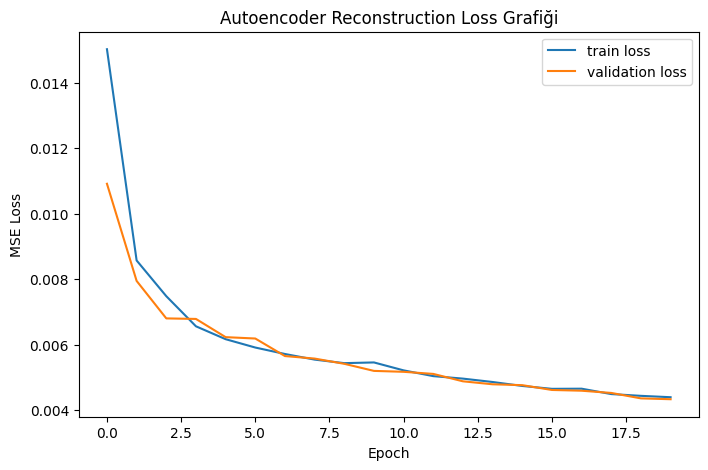

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_ae.history["loss"], label="train loss")
plt.plot(history_ae.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Reconstruction Loss Grafiği")
plt.legend()
plt.show()

## 26. Autoencoder test loss

Bu değer test görüntüleri üzerinde ortalama reconstruction hatasını gösterir. Sınıflandırma olmadığı için accuracy yerine bu loss değerini yorumluyorum.

In [26]:
ae_test_loss = autoencoder.evaluate(ae_test_ds)
print("Autoencoder test reconstruction loss:", ae_test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0043
Autoencoder test reconstruction loss: 0.0042650350369513035


## 27. Orijinal ve yeniden oluşturulan görüntüleri karşılaştırma

Bu hücrede üst sırada orijinal görüntüleri, alt sırada ise modelin yeniden oluşturduğu görüntüleri gösteriyorum. Autoencoder sonuçlarını sadece sayısal loss ile değil görsel olarak da değerlendirmek önemlidir.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step


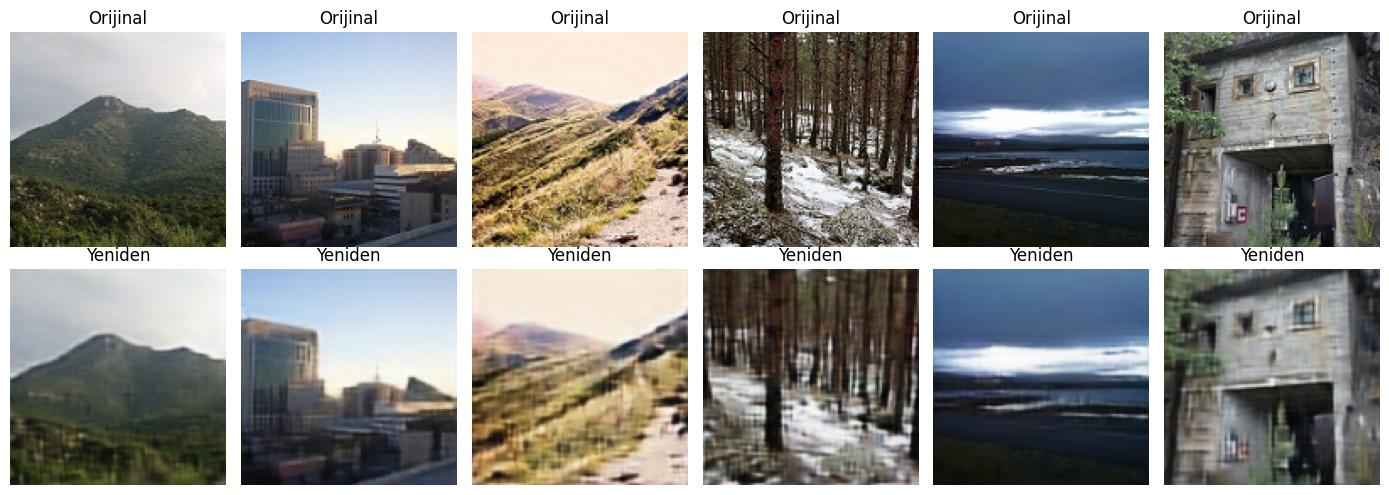

In [27]:
for original_images, target_images in ae_test_ds.take(1):
    reconstructed_images = autoencoder.predict(original_images)

    n = 6
    plt.figure(figsize=(14, 5))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original_images[i].numpy())
        plt.title("Orijinal")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images[i])
        plt.title("Yeniden")
        plt.axis("off")

    plt.tight_layout()
    plt.show()